<a href="https://colab.research.google.com/github/Mogu-code/DataScience/blob/main/Netflix_India_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Netflix Content Strategy Analysis (Focus on India)**

## Objective
This project analyzes Netflix’s global catalog with a focus on India to understand:
- growth of Indian content
- genre preferences
- runtime patterns
- how India differs from global strategy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset
The dataset contains Netflix titles including:
- type (movie/show)
- country
- release year
- genres
- duration

## Key Insights

1. Indian Netflix content has grown significantly after 2016, showing Netflix’s increasing investment in the Indian market.

2. Indian catalog is heavily dominated by movies and drama-driven storytelling, unlike the global catalog which has more TV shows and documentaries.

3. Genres such as romance and musicals are more prominent in India, reflecting local audience preferences.

4. Movie durations in India cluster around 120–140 minutes, suggesting Netflix still follows traditional Bollywood-style runtime patterns rather than short OTT formats.

## Business Recommendations

Based on the analysis, Netflix’s India strategy could benefit from:

- Increasing documentary production to diversify content mix
- Expanding short-format content for mobile-first audiences
- Continuing investment in drama and romance genres which dominate engagement

In [ ]:
df=pd.read_csv("/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df = df.dropna(subset=['country','date_added','rating'])


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


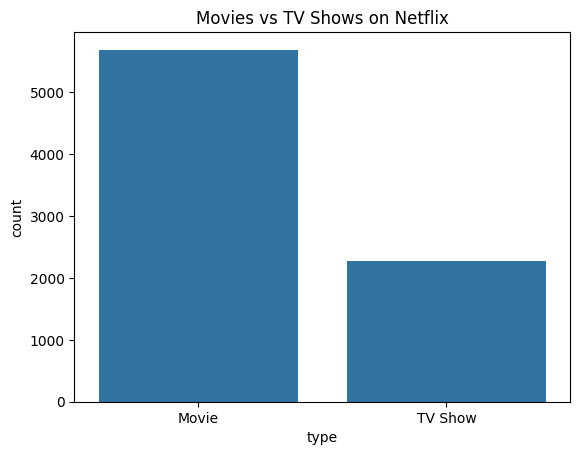

In [ ]:
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

In [ ]:
india_df = df[df['country'].str.contains("India", na=False)]
india_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
29,s30,Movie,Paranoia,Robert Luketic,"Liam Hemsworth, Gary Oldman, Amber Heard, Harr...","United States, India, France","September 19, 2021",2013,PG-13,106 min,Thrillers,"Blackmailed by his company's CEO, a low-level ..."
39,s40,TV Show,Chhota Bheem,NaN,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,"September 16, 2021",2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
50,s51,TV Show,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,"September 15, 2021",2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."


In [ ]:
df['date_added'] = df['date_added'].str.strip()
india_df['date_added'] = india_df['date_added'].str.strip()

/tmp/ipython-input-757149194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_df['date_added'] = india_df['date_added'].str.strip()


In [ ]:
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
india_df['year_added'] = pd.to_datetime(india_df['date_added'], errors='coerce').dt.year

/tmp/ipython-input-1830248770.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_df['year_added'] = pd.to_datetime(india_df['date_added'], errors='coerce').dt.year


In [ ]:
df = df.dropna(subset=['year_added'])
india_df = india_df.dropna(subset=['year_added'])

global trend

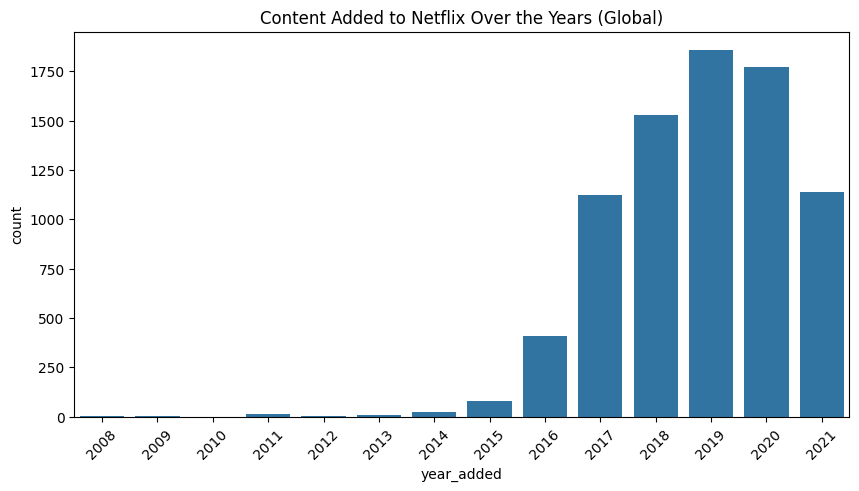

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='year_added')
plt.xticks(rotation=45)
plt.title("Content Added to Netflix Over the Years (Global)")
plt.show()

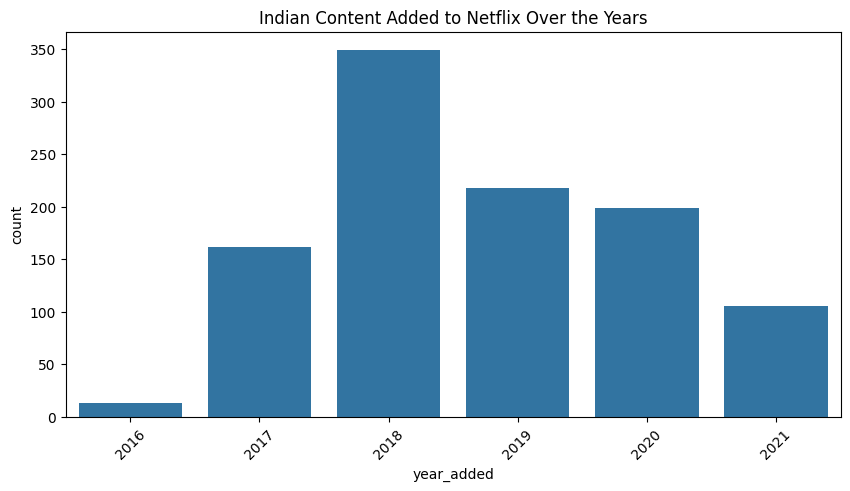

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=india_df, x='year_added')
plt.xticks(rotation=45)
plt.title("Indian Content Added to Netflix Over the Years")
plt.show()

In [ ]:
india_df['listed_in'].head()

,listed_in
4,"International TV Shows, Romantic TV Shows, TV ..."
24,"Comedies, International Movies, Romantic Movies"
29,Thrillers
39,Kids' TV
50,"International TV Shows, TV Dramas, TV Sci-Fi &..."


In [ ]:
# split genres into separate columns
genres = india_df['listed_in'].str.split(',', expand=True)
genres.head()

,0,1,2
4,International TV Shows,Romantic TV Shows,TV Comedies
24,Comedies,International Movies,Romantic Movies
29,Thrillers,None,None
39,Kids' TV,None,None
50,International TV Shows,TV Dramas,TV Sci-Fi & Fantasy


In [ ]:
# Stack genres into one column
genres = genres.stack().str.strip()
genres.value_counts().head(10)

,count
International Movies,864
Dramas,662
Comedies,323
Independent Movies,167
Action & Adventure,137
Romantic Movies,120
Music & Musicals,96
Thrillers,92
International TV Shows,66
Horror Movies,35


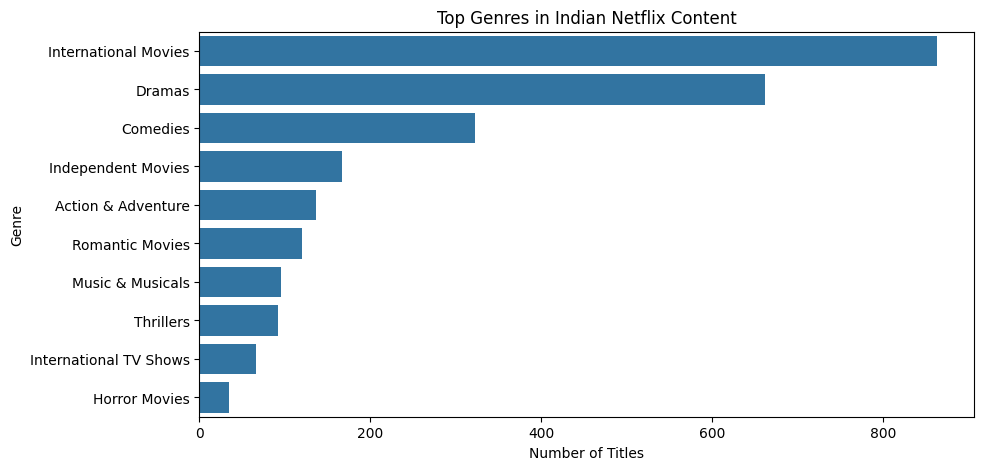

In [ ]:
# plot top 10 india
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres in Indian Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

In [ ]:
# Get global top genres
global_genres = df['listed_in'].str.split(',', expand=True)
global_genres = global_genres.stack().str.strip()

global_top = global_genres.value_counts().head(10)
global_top

,count
International Movies,2543
Dramas,2316
Comedies,1580
International TV Shows,1126
Action & Adventure,817
Documentaries,794
Independent Movies,745
TV Dramas,662
Romantic Movies,588
Thrillers,549


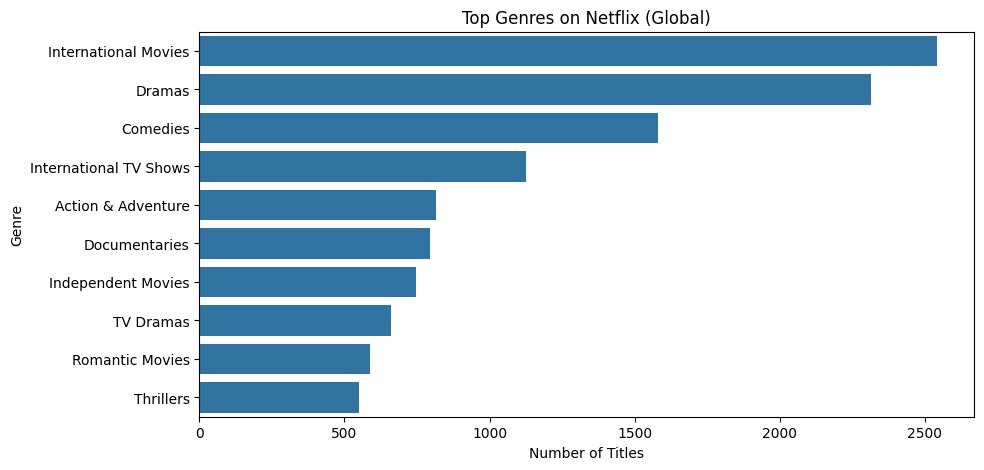

In [ ]:
# plot top 10 global

plt.figure(figsize=(10,5))
sns.barplot(x=global_top.values, y=global_top.index)
plt.title("Top Genres on Netflix (Global)")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

# India chart has:

International Movies

Independent Movies

Romantic Movies

Musicals

# Global chart has:

more TV shows

documentaries

episodic formats

In [ ]:
# Clean duration column
india_movies = india_df[india_df['type'] == 'Movie'].copy()

india_movies['duration'] = india_movies['duration'].str.replace(' min','')
india_movies['duration'] = pd.to_numeric(india_movies['duration'], errors='coerce')

india_movies['duration'].head()

,duration
24,166
29,106
105,128
114,143
116,114


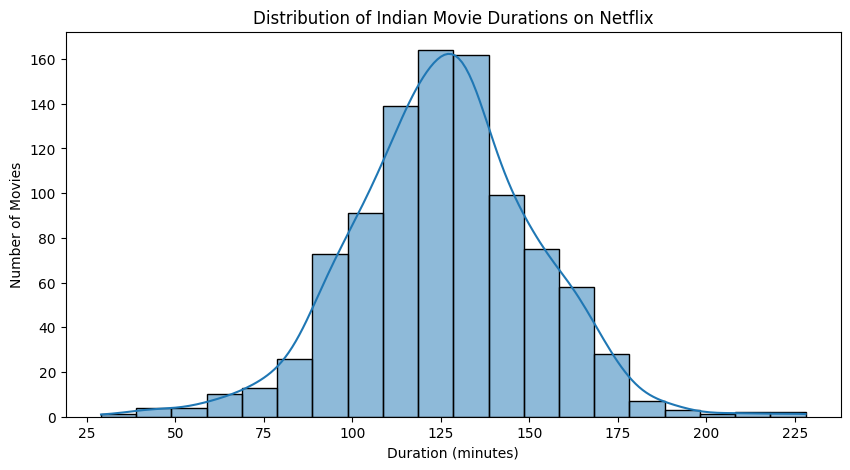

In [ ]:
# lot movie duration distribution
plt.figure(figsize=(10,5))
sns.histplot(india_movies['duration'], bins=20, kde=True)
plt.title("Distribution of Indian Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()